# CASIA-WEBFACE | Face Verification

#### Christian Budhi S

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
torch.set_float32_matmul_precision('high')

# Data Preparation

In [3]:
import struct
import numpy as np
from collections import Counter
import src.constant as C


idx = {}
with open('dataset/casia-webface/train.idx', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        key, offset = line.split('\t')
        idx[int(key)] = int(offset)

labels = []
with open('dataset/casia-webface/train.rec', 'rb') as f:
    for offset in idx.values():
        f.seek(offset)
        f.read(C._IR_BUFFER)
        label = struct.unpack(C._IR_FORMAT, f.read(C._IR_SIZE))[1]
        labels.append(int(label))

counts      = Counter(labels)
sorted_counts = sorted(counts.values(), reverse=True)

low_thresh  = int(np.percentile(sorted_counts, 10))
high_thresh = int(np.percentile(sorted_counts, 80))

high_x = next(i for i, c in enumerate(sorted_counts) if c <= high_thresh)
low_x  = next(i for i, c in enumerate(sorted_counts) if c <= low_thresh)

train_ids = {pid for pid, cnt in counts.items() if low_thresh <= cnt <= high_thresh}
test_ids = {pid for pid, cnt in counts.items() if cnt <= low_thresh or cnt >= high_thresh}

print(f"Keep identities with photos between {high_thresh} and {low_thresh}")
print(f"Identities kept  : {sum(low_thresh <= c <= high_thresh for c in counts.values()):,}  [{sum(c if low_thresh <= c <= high_thresh else 0 for c in counts.values())}]")
print(f"Identities total : {len(counts):,} [{sum(c for c in counts.values())}]")

Keep identities with photos between 57 and 15
Identities kept  : 7,824  [214927]
Identities total : 10,572 [501196]


## Reproducibility

In [4]:
import random, os
import torch
import lightning as L

SEED = 42

L.seed_everything(SEED)

Seed set to 42


42

# Training

In [5]:
from lightning.pytorch.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.tuner import Tuner

# trainer
from src.trainer import *
from src.datamodule import *
from src.simpleCNN import *
from src.efficientNet import *

# pretrained
from torchvision import models

## Training Setup

In [6]:
from torchvision import transforms

# config
IMAGE_SIZE = 112
N_FOLDS = 3
MAX_EPOCH = 30
EARLY_STOPPING_PATIENCE = 5
BATCH_SIZE = 256
PRECISION = 'bf16-mixed'
EMBED_DIM = 256
LEARNING_RATE = 3e-4

# imagenet default transformation
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# testing dataset
TEST_NAMES = ['rec_test', 'lfw', 'cfp_fp', 'agedb_30', 'sllfw', 'talfw']
EVAL_BINS = {
    'lfw'      : 'dataset/eval/lfw.bin',
    'cfp_fp'   : 'dataset/eval/cfp_fp.bin',
    'agedb_30' : 'dataset/eval/agedb_30.bin',
    'sllfw'    : 'dataset/eval/sllfw.bin',
    'talfw'    : 'dataset/eval/talfw.bin',
}

## Find best Learning Rate (Sensitifity Analysis)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

lr_candidates = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
results = []

for lr in lr_candidates:
    L.seed_everything(SEED, workers=True)

    dm_s = KFoldFaceDataModule(
        rec_path        = 'dataset/casia-webface/train.rec',
        idx_path        = 'dataset/casia-webface/train.idx',
        train_ids       = train_ids,
        test_ids        = test_ids,
        eval_bins       = EVAL_BINS,
        train_transform = train_tf,
        val_transform   = val_tf,
        batch_size      = BATCH_SIZE,
        num_workers     = 4,
        seed            = SEED,
        n_folds         = N_FOLDS,
        fold            = 0,
    )

    model_s = SiameseLightningModule(
        backbone = EfficientNetBackbone(embed_dim=EMBED_DIM),
        lr       = lr,
    )

    trainer_s = L.Trainer(
        max_epochs              = 1,
        accelerator             = 'auto',
        precision               = PRECISION,
        logger                  = False,
        enable_progress_bar     = False,
        enable_checkpointing    = False,
        enable_model_summary    = False,
        gradient_clip_val       = 1.0,
        gradient_clip_algorithm = 'norm',
    )

    trainer_s.fit(model_s, dm_s)

    metrics = trainer_s.callback_metrics
    results.append({
        'lr'                    : lr,
        'val_loss'        : metrics.get('val/loss', torch.tensor(float('nan'))).item(),
        'val_auc'               : metrics.get('val/auc',  torch.tensor(float('nan'))).item(),
        'val_f1'                : metrics.get('val/f1',   torch.tensor(float('nan'))).item(),
    })
    print(f"lr={lr:.0e}  val/loss={results[-1]['val_loss']:.4f} val/auc={results[-1]['val_auc']:.4f} val/f1={results[-1]['val_f1']:.4f}")

df = pd.DataFrame(results)

Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42


lr=1e-02  val/loss=0.1278 val/auc=0.9012 val/f1=0.7404


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42


lr=3e-03  val/loss=0.1319 val/auc=0.8958 val/f1=0.7363


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42


...

lr=1e-04  val/loss=0.2825 val/auc=0.6263 val/f1=0.6651


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42


lr=3e-05  val/loss=16.1295 val/auc=0.5972 val/f1=0.2235


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.


lr=1e-05  val/loss=72.0110 val/auc=0.6049 val/f1=0.2235


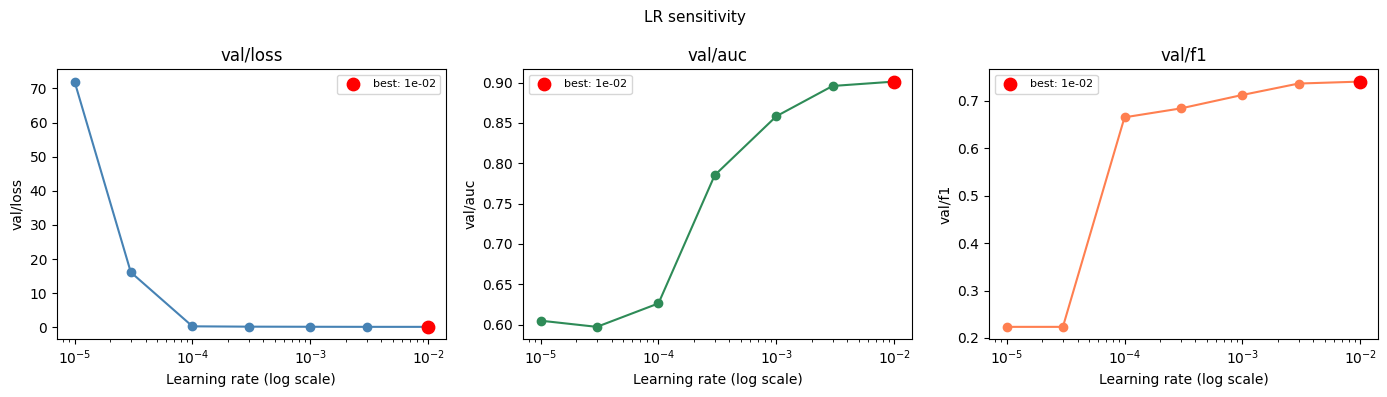

In [8]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['val_loss', 'val_auc', 'val_f1'],
                                  ['steelblue', 'seagreen', 'coral']):
    ax.plot(df['lr'], df[col], marker='o', color=color, linewidth=1.5)
    ax.set_xscale('log')
    ax.set_xlabel('Learning rate (log scale)')
    ax.set_ylabel(col.replace('_', '/'))
    ax.set_title(col.replace('_', '/'))

    # mark best
    best_idx = df[col].idxmin() if col == 'val_loss' else df[col].idxmax()
    ax.scatter(df.loc[best_idx, 'lr'], df.loc[best_idx, col],
               color='red', zorder=5, s=80, label=f"best: {df.loc[best_idx, 'lr']:.0e}")
    ax.legend(fontsize=8)

plt.suptitle('LR sensitivity', fontsize=11)
plt.tight_layout()
plt.show()

In [14]:
dm_lr = KFoldFaceDataModule(
    rec_path        = 'dataset/casia-webface/train.rec',
    idx_path        = 'dataset/casia-webface/train.idx',
    train_ids       = train_ids,
    test_ids        = test_ids,
    eval_bins       = EVAL_BINS,
    train_transform = train_tf,
    val_transform   = val_tf,
    batch_size      = BATCH_SIZE,
    num_workers     = 4,
    seed            = SEED,
    n_folds         = N_FOLDS,
    fold            = 0,
    mode            = TrainMode.ARCFACE
)

num_classes = len(train_ids)

model_lr = ArcFaceLightningModule(
        backbone    = EfficientNetBackbone(embed_dim=EMBED_DIM),
        num_classes = num_classes,
        embed_dim   = EMBED_DIM,
        lr          = 1e-4,
        s           = 32.0,
        m           = 0.3,
        test_names  = TEST_NAMES
    )

trainer_lr = L.Trainer(
    max_epochs  = 1,
    accelerator = 'auto',
    precision   = PRECISION,
    logger      = False,
    enable_checkpointing = False,
)

tuner      = Tuner(trainer_lr)
lr_finder  = tuner.lr_find(
    model_lr,
    datamodule=dm_lr,
    min_lr=1e-9,
    max_lr=10,
    num_training=100,
    early_stop_threshold=4.0,
)
suggested  = lr_finder.suggestion()

print(f"Suggested LR: {suggested:.2e}")

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at e:\S2\Visi Komputer\Face Verification\.lr_find_6436e69e-20ce-4e57-aa0a-53ecaad91910.ckpt
Restored all states from the checkpoint at e:\S2\Visi Komputer\Face Verification\.lr_find_6436e69e-20ce-4e57-aa0a-53ecaad91910.ckpt
Learning rate set to 0.003162277660168381


Suggested LR: 3.16e-03


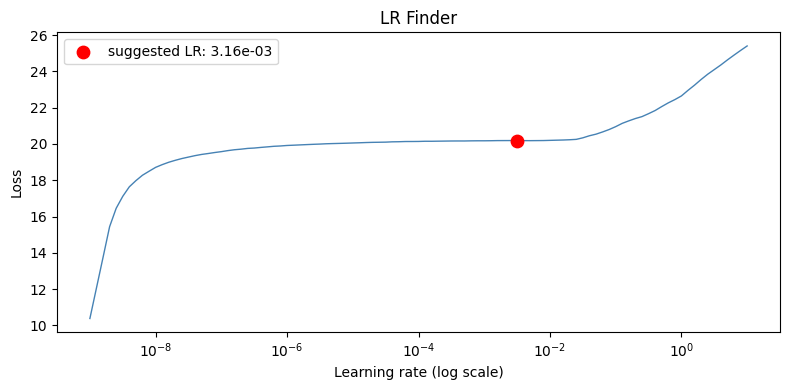

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lr_finder.results['lr'], lr_finder.results['loss'], linewidth=1, color='steelblue')
ax.scatter(suggested, lr_finder.results['loss'][
    lr_finder.results['lr'].index(suggested)
], color='red', zorder=5, s=80, label=f'suggested LR: {suggested:.2e}')
ax.set_xscale('log')
ax.set_xlabel('Learning rate (log scale)')
ax.set_ylabel('Loss')
ax.set_title('LR Finder')
ax.legend()
plt.tight_layout()
plt.show()

## Siamese Training

In [16]:
from src.callbacks import *

for fold in range(N_FOLDS):
    L.seed_everything(SEED, workers=True)
    
    dm = KFoldFaceDataModule(
        rec_path        = 'dataset/casia-webface/train.rec',
        idx_path        = 'dataset/casia-webface/train.idx',
        train_ids       = train_ids,
        test_ids        = test_ids,
        eval_bins       = EVAL_BINS,
        train_transform = train_tf,
        val_transform   = val_tf,
        batch_size      = BATCH_SIZE,
        num_workers     = 4,
        seed            = SEED,
        n_folds         = N_FOLDS,
        fold            = fold,
        mode            = TrainMode.CONTRASTIVE
    )

    model = SiameseLightningModule(
        backbone    = EfficientNetBackbone(embed_dim=EMBED_DIM),
        lr          = 3e-3,
        test_names  = TEST_NAMES
    )

    logger = TensorBoardLogger(
        save_dir = 'tb_logs',
        name     = 'effnet_contrastive_face',
        version  = f'fold_{fold}',
    )

    callbacks = [
        ModelCheckpoint(
            monitor   = 'val/auc',
            mode      = 'max',
            save_top_k = 1,
            filename  = f'fold{fold}_best',
        ),
        EarlyStopping(
            monitor  = 'val/loss',
            patience = EARLY_STOPPING_PATIENCE,
            mode     = 'min',
        ),
        LearningRateMonitor(logging_interval='epoch')
    ]

    trainer = L.Trainer(
        max_epochs              = MAX_EPOCH,
        logger                  = logger,
        callbacks               = callbacks,
        accelerator             = 'auto',
        precision               = PRECISION,
        log_every_n_steps       = 50,
        gradient_clip_val       = 1.0,
        gradient_clip_algorithm = 'norm',
    )

    trainer.fit(model, dm)
    trainer.test(model, dm, ckpt_path='best')

    print(f"Fold {fold} outputs -> {logger.log_dir}")

Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\ChristianBudhi\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone │ EfficientNetBackbone   │  4.3 M │ train │     0 │
│ 1 │ val_acc  │ BinaryAccuracy         │      0 │ train │     0 │
│ 2 │ val_f1   │ BinaryF1Score          │      0 │ train │     0 │
│ 3 │ val_auc  │ BinaryAUROC            │      0 │ train │     0 │
│ 4 │ val_ap   │ BinaryAveragePrecision │      0 │ train │     0 │
│ 5 │ test_acc │ BinaryAccuracy         │      0 │ train │     0 │
│ 6 │ test_f1  │ BinaryF1Score          │      0 │ train │     0 │
│ 7 │ test_auc │ BinaryAUROC            │      0 │ train │     0 │
│ 8 │ test_ap  │ BinaryAveragePrecision │      0 │ train │     0 │
└───┴──────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 4.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.3 M                                                                                                
Total estimated model params size (MB): 17                                                                         
Modules in train mode: 346                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Seed set to 42
Restoring states from the checkpoint path at tb_logs\effnet_contrastive_face\fold_0\checkpoints\fold0_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at tb_logs\effnet_contrastive_face\fold_0\checkpoints\fold0_best.ckpt


...

Seed set to 42
Restoring states from the checkpoint path at tb_logs\effnet_contrastive_face\fold_2\checkpoints\fold2_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at tb_logs\effnet_contrastive_face\fold_2\checkpoints\fold2_best.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.7037551403045654     │    0.7037551403045654     │    0.7037551403045654     │
│          test/ap          │     0.876359224319458     │     0.876359224319458     │     0.876359224319458     │
│         test/auc          │    0.8952811360359192     │    0.8952811360359192     │    0.8952811360359192     │
│          test/f1          │    0.7706974744796753     │    0.7706974744796753     │    0.7706974744796753     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 3        ┃       DataLoader 4        ┃       DataLoader 5        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.7037551403045654     │    0.7037551403045654     │    0.7037551403045654     │
│          test/ap          │     0.876359224319458     │     0.876359224319458     │     0.876359224319458     │
│         test/auc          │    0.8952811360359192     │    0.8952811360359192     │    0.8952811360359192     │
│          test/f1          │    0.7706974744796753     │    0.7706974744796753     │    0.7706974744796753     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

Fold 2 outputs -> tb_logs\effnet_contrastive_face\fold_2


## ArcFace Training

In [18]:
from src.callbacks import *

for fold in range(N_FOLDS):
    L.seed_everything(SEED, workers=True)
    
    dm = KFoldFaceDataModule(
        rec_path        = 'dataset/casia-webface/train.rec',
        idx_path        = 'dataset/casia-webface/train.idx',
        train_ids       = train_ids,
        test_ids        = test_ids,
        eval_bins       = EVAL_BINS,
        train_transform = train_tf,
        val_transform   = val_tf,
        batch_size      = BATCH_SIZE,
        num_workers     = 4,
        seed            = SEED,
        n_folds         = N_FOLDS,
        fold            = fold,
        mode            = TrainMode.ARCFACE
    )
    
    num_classes = len(train_ids)

    model = ArcFaceLightningModule(
        backbone    = EfficientNetBackbone(embed_dim=EMBED_DIM),
        num_classes = num_classes,
        embed_dim   = EMBED_DIM,
        lr          = 3e-4,
        s           = 32.0,
        m           = 0.3,
        test_names  = TEST_NAMES
    )

    logger = TensorBoardLogger(
        save_dir = 'tb_logs',
        name     = 'effnet_arcface_face',
        version  = f'fold_{fold}',
    )

    callbacks = [
        ModelCheckpoint(
            monitor   = 'val/auc',
            mode      = 'max',
            save_top_k = 1,
            filename  = f'fold{fold}_best',
        ),
        EarlyStopping(
            monitor  = 'val/auc',
            patience = EARLY_STOPPING_PATIENCE,
            mode     = 'max',
        ),
        LearningRateMonitor(logging_interval='epoch')
    ]

    trainer = L.Trainer(
        max_epochs              = MAX_EPOCH,
        logger                  = logger,
        callbacks               = callbacks,
        accelerator             = 'auto',
        precision               = PRECISION,
        log_every_n_steps       = 50,
        gradient_clip_val       = 0.5,
        gradient_clip_algorithm = 'norm',
    )

    trainer.fit(model, dm)
    trainer.test(model, dm, ckpt_path='best')

    print(f"Fold {fold} outputs -> {logger.log_dir}")

Seed set to 42
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
Seed set to 42
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\ChristianBudhi\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone │ EfficientNetBackbone   │  4.3 M │ train │     0 │
│ 1 │ loss_fn  │ ArcFaceLoss            │  2.0 M │ train │     0 │
│ 2 │ val_acc  │ BinaryAccuracy         │      0 │ train │     0 │
│ 3 │ val_f1   │ BinaryF1Score          │      0 │ train │     0 │
│ 4 │ val_auc  │ BinaryAUROC            │      0 │ train │     0 │
│ 5 │ val_ap   │ BinaryAveragePrecision │      0 │ train │     0 │
│ 6 │ test_acc │ BinaryAccuracy         │      0 │ train │     0 │
│ 7 │ test_f1  │ BinaryF1Score          │      0 │ train │     0 │
│ 8 │ test_auc │ BinaryAUROC            │      0 │ train │     0 │
│ 9 │ test_ap  │ BinaryAveragePrecision │      0 │ train │     0 │
└───┴──────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 6.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.3 M                                                                                                
Total estimated model params size (MB): 25                                                                         
Modules in train mode: 347                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\ChristianBudhi\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:209: 
UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. 
Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the 
closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to 
replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)

...

Seed set to 42
Restoring states from the checkpoint path at tb_logs\effnet_arcface_face\fold_2\checkpoints\fold2_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at tb_logs\effnet_arcface_face\fold_2\checkpoints\fold2_best.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │     0.596528172492981     │     0.596528172492981     │     0.596528172492981     │
│          test/ap          │    0.9352679252624512     │    0.9352679252624512     │    0.9352679252624512     │
│         test/auc          │    0.9217827320098877     │    0.9217827320098877     │    0.9217827320098877     │
│          test/f1          │    0.3257749080657959     │    0.3257749080657959     │    0.3257749080657959     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 3        ┃       DataLoader 4        ┃       DataLoader 5        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │     0.596528172492981     │     0.596528172492981     │     0.596528172492981     │
│          test/ap          │    0.9352679252624512     │    0.9352679252624512     │    0.9352679252624512     │
│         test/auc          │    0.9217827320098877     │    0.9217827320098877     │    0.9217827320098877     │
│          test/f1          │    0.3257749080657959     │    0.3257749080657959     │    0.3257749080657959     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

Fold 2 outputs -> tb_logs\effnet_arcface_face\fold_2
